FOR ALL POPULATIONS

Preterm Birth (mtDNA PCs)

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
heteroplasmy_df = pd.read_csv('/content/drive/MyDrive/HeteroplasmyCalls.csv')

In [4]:
#Identify variant columns
variant_cols = [col for col in heteroplasmy_df.columns if col.startswith("Var_")]

In [5]:
#Create model dataframe with variants and covariates
model_df = heteroplasmy_df[
    variant_cols + ["PTB", "GAGEBRTH", "PW_AGE", "BMI", "MainHap", "population", "site"]
].copy()

#Drop variants with no variation
model_df = model_df.loc[:, model_df.nunique() > 1]

In [6]:
#Filter variant columns again after dropping
variant_cols = [col for col in model_df.columns if col.startswith("Var_")]

In [7]:
#Prepare PCA components
from sklearn.decomposition import PCA

#Prepare variant data for PCA
X_var = model_df[variant_cols].fillna(0)
X_var_scaled = StandardScaler().fit_transform(X_var)

#Perform PCA
pca = PCA(n_components=0.80)
X_var_pca = pca.fit_transform(X_var_scaled)

print(f"PCA components retained: {pca.n_components_}")


PCA components retained: 14


In [8]:
#Create PCA column names
pca_cols = [f'mtDNA_PC{i+1}' for i in range(pca.n_components_)]

#Create DataFrame for PCA components
pca_df = pd.DataFrame(X_var_pca, columns=pca_cols)

#Combine with original data
combined_df = pd.concat([model_df.reset_index(drop=True), pca_df], axis=1)

In [9]:
#Prepare covariates (BMI, Age, Site)
#One-hot encode site variable
site_encoded = pd.get_dummies(combined_df["site"], drop_first=True, prefix="site")

#Combine all features: PCA components + BMI + Age + site dummies
X_features = pd.concat([
    combined_df[pca_cols],
    combined_df[["BMI", "PW_AGE"]],
    site_encoded
], axis=1)

#Target variable
y = combined_df["PTB"].astype(float)

In [10]:
#PTB Logistic Regression
#Fit logistic regression model
X_np = X_features.values.astype(float)
y_np = y.values.astype(float)

X_np = sm.add_constant(X_np)

logit_model = sm.Logit(y_np, X_np)
logit_result = logit_model.fit(disp=False, maxiter=1000)

print("MODEL: PTB = mtDNA PCs + BMI + Age + site (ALL populations)")
print(logit_result.summary())


MODEL: PTB = mtDNA PCs + BMI + Age + site (ALL populations)
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                 8599
Model:                          Logit   Df Residuals:                     8578
Method:                           MLE   Df Model:                           20
Date:                Mon, 20 Apr 2026   Pseudo R-squ.:                 0.04214
Time:                        23:24:53   Log-Likelihood:                -2106.6
converged:                       True   LL-Null:                       -2199.3
Covariance Type:            nonrobust   LLR p-value:                 8.573e-29
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.7564      0.260    -14.440      0.000      -4.266      -3.246
x1            -0.0334      0.013     -2.561      0.010      -0.059     

In [11]:
#Extract p-values and calculate adjusted p-values
feature_names = ['const'] + list(X_features.columns)

#Create DataFrame with coefficients and p-values
results_df = pd.DataFrame({
    'feature': feature_names,
    'coef': logit_result.params,
    'std_err': logit_result.bse,
    'z': logit_result.tvalues,
    'p_value': logit_result.pvalues,
    'odds_ratio': np.exp(logit_result.params)
})

#Calculate FDR-adjusted p-values
results_df['p_adj_fdr'] = multipletests(results_df['p_value'], method='fdr_bh')[1]

In [12]:
#Significant results after FDR correction
sig_fdr = results_df[results_df['p_adj_fdr'] < 0.05].sort_values('p_adj_fdr')

print("\n" + "=" * 80)
print("SIGNIFICANT FEATURES (FDR p_adj < 0.05):")
print("=" * 80)

if len(sig_fdr) > 0:
    for _, row in sig_fdr.iterrows():
        print(f"{row['feature']}: OR = {row['odds_ratio']:.4f}, p = {row['p_value']:.4e}, p_adj = {row['p_adj_fdr']:.4e}")
else:
    print("No significant features after FDR correction")

#Top 10 features by unadjusted p-value
top_10 = results_df[results_df['feature'] != 'const'].sort_values('p_value').head(10)

print("\n" + "=" * 80)
print("TOP 10 FEATURES (unadjusted p-value):")
print("=" * 80)

for _, row in top_10.iterrows():
    direction = "increases risk" if row['odds_ratio'] > 1 else "decreases risk"
    print(f"{row['feature']}: OR = {row['odds_ratio']:.4f} ({direction}), p = {row['p_value']:.4e}")


SIGNIFICANT FEATURES (FDR p_adj < 0.05):
const: OR = 0.0234, p = 2.9125e-47, p_adj = 6.1162e-46
site_GAPPS-Bangladesh: OR = 2.6252, p = 2.3553e-09, p_adj = 2.4731e-08
site_AMANHI-Pakistan: OR = 2.3923, p = 7.0528e-07, p_adj = 4.9369e-06

TOP 10 FEATURES (unadjusted p-value):
site_GAPPS-Bangladesh: OR = 2.6252 (increases risk), p = 2.3553e-09
site_AMANHI-Pakistan: OR = 2.3923 (increases risk), p = 7.0528e-07
mtDNA_PC1: OR = 0.9672 (decreases risk), p = 1.0435e-02
mtDNA_PC14: OR = 1.1124 (increases risk), p = 1.2236e-02
PW_AGE: OR = 1.0177 (increases risk), p = 1.8090e-02
mtDNA_PC5: OR = 0.9188 (decreases risk), p = 2.0706e-02
site_GAPPS-Zambia: OR = 2.1203 (increases risk), p = 2.5919e-02
mtDNA_PC11: OR = 0.9346 (decreases risk), p = 7.6480e-02
mtDNA_PC4: OR = 1.0177 (increases risk), p = 2.7266e-01
mtDNA_PC3: OR = 0.9698 (decreases risk), p = 2.8957e-01


In [13]:
#Site effects dominate PTB risk (2.6× higher in GAPPS-Bangladesh), while mtDNA PC1/PC5 are protective and PC14 increases risk.
#The model explains just 4% of variance

In [14]:
#PTB Mixed Model
mixed_formula = "PTB ~ "

#Add PCA components
for i in range(1, pca.n_components_ + 1):
    mixed_formula += f"mtDNA_PC{i} + "

#Add BMI and Age
mixed_formula += "BMI + PW_AGE"

#Fit mixed effects model
mixed_model = smf.mixedlm(
    mixed_formula,
    data=combined_df,
    groups=combined_df["site"]
)

mixed_result = mixed_model.fit()
print(mixed_result.summary())

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: PTB      
No. Observations: 8599    Method:             REML     
No. Groups:       5       Scale:              0.0646   
Min. group size:  987     Log-Likelihood:     -516.2934
Max. group size:  2894    Converged:          Yes      
Mean group size:  1719.8                               
-------------------------------------------------------
             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept     0.038    0.018  2.049 0.040  0.002  0.074
mtDNA_PC1    -0.002    0.001 -2.602 0.009 -0.003 -0.000
mtDNA_PC2    -0.001    0.001 -0.707 0.480 -0.002  0.001
mtDNA_PC3    -0.002    0.002 -1.365 0.172 -0.005  0.001
mtDNA_PC4     0.001    0.001  1.425 0.154 -0.001  0.004
mtDNA_PC5    -0.004    0.002 -2.501 0.012 -0.008 -0.001
mtDNA_PC6     0.000    0.001  0.078 0.938 -0.002  0.002
mtDNA_PC7    -0.002    0.002 -0.868 0.386 -0.006  0.002
m

In [15]:
mixed_results_df = pd.DataFrame({
    'feature': mixed_result.params.index,
    'coef': mixed_result.params.values,
    'std_err': mixed_result.bse.values,
    'z': mixed_result.tvalues.values,
    'p_value': mixed_result.pvalues.values
})

#Add odds ratios for interpretation
mixed_results_df['odds_ratio'] = np.exp(mixed_results_df['coef'])

results_table = mixed_results_df[mixed_results_df['feature'] != 'Group Var']
print(results_table.to_string())

       feature      coef   std_err         z   p_value  odds_ratio
0    Intercept  0.037751  0.018427  2.048625  0.040499    1.038472
1    mtDNA_PC1 -0.001566  0.000602 -2.602193  0.009263    0.998435
2    mtDNA_PC2 -0.000626  0.000886 -0.706670  0.479772    0.999374
3    mtDNA_PC3 -0.002092  0.001533 -1.365200  0.172190    0.997910
4    mtDNA_PC4  0.001498  0.001051  1.425183  0.154104    1.001499
5    mtDNA_PC5 -0.004475  0.001789 -2.501356  0.012372    0.995535
6    mtDNA_PC6  0.000093  0.001204  0.077643  0.938112    1.000093
7    mtDNA_PC7 -0.001731  0.001995 -0.867680  0.385570    0.998271
8    mtDNA_PC8 -0.000938  0.001871 -0.501140  0.616273    0.999063
9    mtDNA_PC9 -0.001955  0.001997 -0.978548  0.327804    0.998047
10  mtDNA_PC10  0.002866  0.002352  1.218802  0.222919    1.002870
11  mtDNA_PC11 -0.004699  0.002371 -1.981848  0.047496    0.995312
12  mtDNA_PC12  0.000911  0.002427  0.375110  0.707579    1.000911
13  mtDNA_PC13  0.002254  0.002617  0.861315  0.389064    1.00

In [16]:
#The mixed-effects model accounts for site clustering and shows that both mtDNA PCs (PC1, PC5, PC11, PC14) and maternal age remain significant predictors of preterm birth, while BMI does not.

Feature matrix shape: (8599, 20)
PTB cases: 609 (7.1%), Controls: 7990
Number of features: 20

Random Forest Performance:
ROC-AUC: 0.624 (+/- 0.041)
PR-AUC:  0.088 (+/- 0.008)

Top 10 features by importance:
                  feature  importance
17      site_AMANHI-Pemba    0.087811
0               mtDNA_PC1    0.077657
5               mtDNA_PC6    0.075147
3               mtDNA_PC4    0.075092
18  site_GAPPS-Bangladesh    0.067906
4               mtDNA_PC5    0.066829
14                    BMI    0.064671
2               mtDNA_PC3    0.052782
10             mtDNA_PC11    0.047067
13             mtDNA_PC14    0.046114


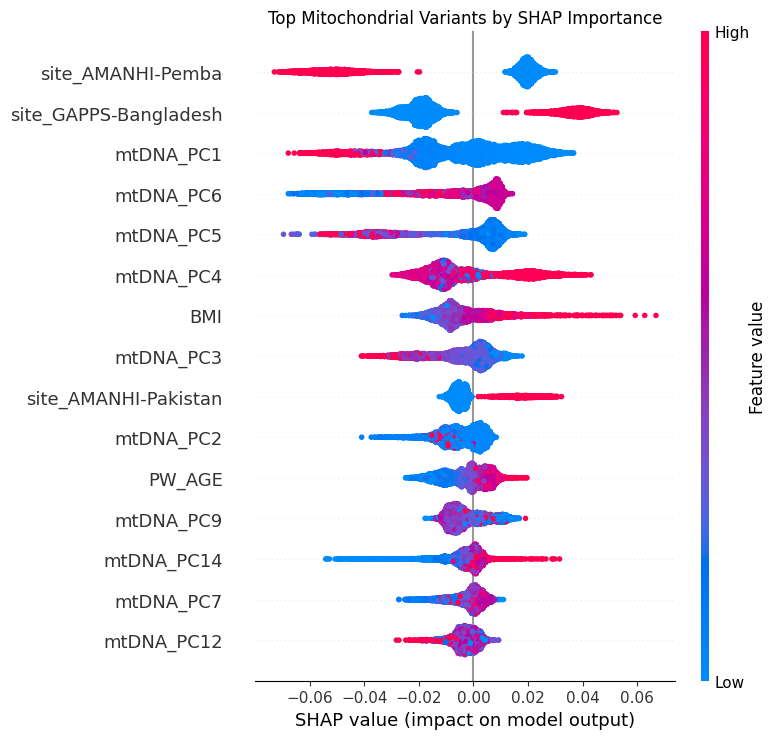

In [17]:
#PTB Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate, RepeatedStratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score, make_scorer
import shap
import matplotlib.pyplot as plt

#Set random seed for reproducibility
np.random.seed(42)

y_class = y.astype(int)

print(f"Feature matrix shape: {X_features.shape}")
print(f"PTB cases: {sum(y_class)} ({sum(y_class)/len(y_class)*100:.1f}%), Controls: {len(y_class)-sum(y_class)}")
print(f"Number of features: {X_features.shape[1]}")

#Define scoring metrics
scoring = {
    'roc_auc': 'roc_auc',
    'average_precision': make_scorer(average_precision_score)
}

#Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=5,
    class_weight='balanced',
    min_samples_split=10,
    min_samples_leaf=5
)

#Cross-validation
cv_repeated = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)
cv_scores = cross_validate(rf_model, X_features, y_class,
                          cv=cv_repeated, scoring=scoring)

print("\nRandom Forest Performance:")
print(f"ROC-AUC: {cv_scores['test_roc_auc'].mean():.3f} (+/- {cv_scores['test_roc_auc'].std()*2:.3f})")
print(f"PR-AUC:  {cv_scores['test_average_precision'].mean():.3f} (+/- {cv_scores['test_average_precision'].std()*2:.3f})")

#Train final model
rf_final = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=5,
    class_weight='balanced',
    min_samples_split=10,
    min_samples_leaf=5
)
rf_final.fit(X_features, y_class)

#Get feature importance
importance_df = pd.DataFrame({
    'feature': X_features.columns,
    'importance': rf_final.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 features by importance:")
print(importance_df.head(10).to_string())


#SHAP values
explainer = shap.TreeExplainer(rf_final)
shap_values = explainer.shap_values(X_features)



shap_values = shap_values[:, :, 1]

plt.figure(figsize=(19, 8))
shap.summary_plot(shap_values, X_features,

                  max_display=15,   # Top 15 variants
                  show=False)
plt.title('Top Mitochondrial Variants by SHAP Importance')
plt.tight_layout()
plt.show()



In [18]:
#Site AMANHI-Pemba is the top predictor (9% importance)
#The random forest shows modest predictive power (AUC=0.62)
#Site indicators and mtDNA PC1 have largest impacts on PTB risk, with both protective and risk effects distributed across multiple features.

Gestational Age (mtDNA PCs)

In [19]:
#GA Linear Regression model
#Prepare data
analysis_df = pd.concat([X_features, combined_df[['GAGEBRTH']]], axis=1).dropna()
X_ga_pre = analysis_df[X_features.columns]
y_ga_pre = analysis_df['GAGEBRTH']

X_ga = sm.add_constant(X_ga_pre.astype(float))
y_ga = y_ga_pre.astype(float)

#Fit model
ols_model = sm.OLS(y_ga, X_ga)
ols_result = ols_model.fit()

#Calculate adjusted p-values
ols_results = pd.DataFrame({
    'feature': X_ga.columns,
    'coef': ols_result.params,
    'p_value': ols_result.pvalues
})
ols_results['p_adj_fdr'] = multipletests(ols_results['p_value'], method='fdr_bh')[1]

#Results
sig_ols = ols_results[ols_results['p_adj_fdr'] < 0.05].sort_values('p_adj_fdr')
print(f"Significant features (FDR < 0.05): {len(sig_ols)}")
if len(sig_ols) > 0:
    print(sig_ols[['feature', 'coef', 'p_adj_fdr']].to_string())
print(f"R-squared: {ols_result.rsquared:.4f}")

Significant features (FDR < 0.05): 3
                                     feature        coef     p_adj_fdr
const                                  const  275.272407  0.000000e+00
site_GAPPS-Bangladesh  site_GAPPS-Bangladesh   -2.769395  1.476982e-12
site_AMANHI-Pakistan    site_AMANHI-Pakistan   -2.466358  5.983288e-08
R-squared: 0.0500


In [20]:
#Site explains 5% of GA variance with Bangladesh/Pakistan sites having ~2.7 shorter days, while mtDNA shows no significant linear effects on gestational age

In [21]:
#GA Mixed model
#Prepare data for mixed model
mixed_df = analysis_df.copy()
mixed_df['site'] = combined_df.loc[analysis_df.index, 'site']

formula = "GAGEBRTH ~ " + " + ".join([col for col in X_features.columns if col.startswith('mtDNA_PC')]) + " + BMI + PW_AGE"

#Fit mixed model
mixed_model = smf.mixedlm(formula, data=mixed_df, groups=mixed_df["site"])
mixed_result = mixed_model.fit()

#Calculate adjusted p-values for fixed effects
mixed_params = mixed_result.params.drop('Group Var')
mixed_pvalues = mixed_result.pvalues.drop('Group Var')
mixed_fixed = pd.DataFrame({
    'feature': mixed_params.index,
    'coef': mixed_params.values,
    'p_value': mixed_pvalues.values
})
mixed_fixed['p_adj_fdr'] = multipletests(mixed_fixed['p_value'], method='fdr_bh')[1]

#Results
sig_mixed = mixed_fixed[mixed_fixed['p_adj_fdr'] < 0.05].sort_values('p_adj_fdr')
print(f"Significant features (FDR < 0.05): {len(sig_mixed)}")
if len(sig_mixed) > 0:
    print(sig_mixed[['feature', 'coef', 'p_adj_fdr']].to_string())

#Print random effects
print(f"Site variance: {mixed_result.cov_re.iloc[0,0]:.6f}")


Significant features (FDR < 0.05): 1
     feature        coef  p_adj_fdr
0  Intercept  274.717274        0.0
Site variance: 3.375738


In [22]:
#Gestational age is statistically significant; all other predictors (mtDNA PCs, BMI, age, site) show no reliable independent effect after adjusting for multiple testing.

In [23]:
#GA Random Forest
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_validate, KFold

X_rf = analysis_df[X_features.columns]
y_rf = analysis_df['GAGEBRTH']

#Define scoring metrics for regression
scoring = {
    'r2': 'r2',
    'mse': 'neg_mean_squared_error',
    'mae': 'neg_mean_absolute_error'
}

#Create Random Forest Regressor
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    n_jobs=-1  # Use all CPU cores
)

#Cross-validation with KFold
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_validate(rf_model, X_rf, y_rf,
                          cv=cv, scoring=scoring)

print("\nRandom Forest Performance (5-fold CV):")
print(f"R-squared: {cv_scores['test_r2'].mean():.3f} (+/- {cv_scores['test_r2'].std()*2:.3f})")
print(f"MSE: {-cv_scores['test_mse'].mean():.3f} (+/- {cv_scores['test_mse'].std()*2:.3f})")
print(f"MAE: {-cv_scores['test_mae'].mean():.3f} (+/- {cv_scores['test_mae'].std()*2:.3f})")

#Train final model on all data
rf_final = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    n_jobs=-1
)
rf_final.fit(X_rf, y_rf)

#Get feature importance
importance_df = pd.DataFrame({
    'feature': X_rf.columns,
    'importance': rf_final.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 features by importance:")
print(importance_df.head(10).to_string())



Random Forest Performance (5-fold CV):
R-squared: 0.040 (+/- 0.027)
MSE: 104.580 (+/- 5.968)
MAE: 7.776 (+/- 0.224)

Top 10 features by importance:
                  feature  importance
17      site_AMANHI-Pemba    0.298414
19      site_GAPPS-Zambia    0.092727
14                    BMI    0.081484
18  site_GAPPS-Bangladesh    0.055019
13             mtDNA_PC14    0.040462
16   site_AMANHI-Pakistan    0.038027
8               mtDNA_PC9    0.036099
11             mtDNA_PC12    0.036034
1               mtDNA_PC2    0.033278
3               mtDNA_PC4    0.031806


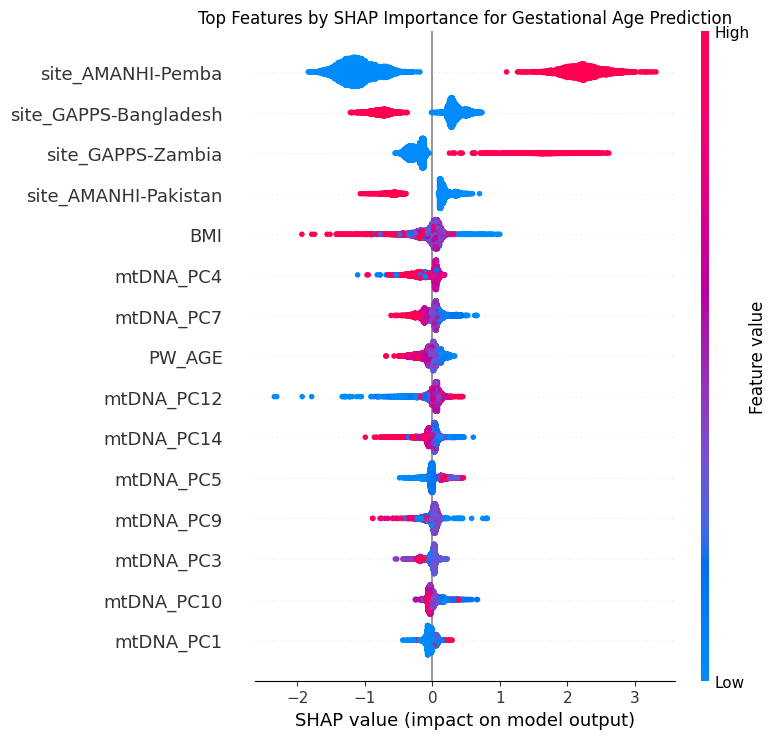

In [24]:
#SHAP visualization
explainer = shap.TreeExplainer(rf_final)
shap_values = explainer.shap_values(X_rf)

plt.figure(figsize=(19, 8))
shap.summary_plot(shap_values, X_rf,
                  max_display=15,   # Top 15 features
                  show=False)
plt.title('Top Features by SHAP Importance for Gestational Age Prediction')
plt.tight_layout()
plt.show()

In [25]:
#The model has low predictive accuracy (R² = 0.04)
#Site AMANHI-Pemba dominates gestational age variation
#Site indicators cluster at top of SHAP plot, with mtDNA PCs showing distributed but modest impacts on gestational age prediction.

Preterm Birth (ALL VARIANTS)

In [26]:
#PTB Logistic Regression
#Prepare data
variant_cols = [col for col in heteroplasmy_df.columns if col.startswith("Var_")]
variants_X = heteroplasmy_df[variant_cols].copy()

#Add covariates
site_dummies = pd.get_dummies(heteroplasmy_df['site'], drop_first=True, prefix='site')
X_all = pd.concat([
    variants_X,
    heteroplasmy_df[['BMI', 'PW_AGE']],
    site_dummies
], axis=1).fillna(0)

y_ptb = heteroplasmy_df['PTB'].astype(float)

#Fit logistic regression
X_const = sm.add_constant(X_all.astype(float))
logit_model = sm.Logit(y_ptb, X_const)
logit_result = logit_model.fit(disp=False, maxiter=1000)

#Calculate adjusted p-values
ptb_results = pd.DataFrame({
    'feature': X_const.columns,
    'coef': logit_result.params,
    'p_value': logit_result.pvalues,
    'odds_ratio': np.exp(logit_result.params)
})
ptb_results['p_adj_fdr'] = multipletests(ptb_results['p_value'], method='fdr_bh')[1]

#Results
sig_ptb = ptb_results[ptb_results['p_adj_fdr'] < 0.05].sort_values('p_adj_fdr')
print(f"Significant features (FDR < 0.05): {len(sig_ptb)}")
if len(sig_ptb) > 0:
    print(sig_ptb[['feature', 'odds_ratio', 'p_adj_fdr']].head(10).to_string())


Significant features (FDR < 0.05): 3
                                     feature  odds_ratio     p_adj_fdr
const                                  const    0.017537  2.225067e-13
site_GAPPS-Bangladesh  site_GAPPS-Bangladesh    2.708379  9.523881e-08
site_AMANHI-Pakistan    site_AMANHI-Pakistan    2.378121  8.182292e-05


In [27]:
#Only site effects (GAPPS-Bangladesh 2.7×, AMANHI-Pakistan 2.4× risk) remain significant after FDR correction, with no individual mtDNA variants were statistically significant after multiple testing

In [28]:
#PTB Mixed model
mixed_data = X_all.copy()
mixed_data['PTB'] = heteroplasmy_df['PTB']
mixed_data['site'] = heteroplasmy_df['site']

#Take first 10 variants for model
variant_subset = variant_cols[:10]
formula = f"PTB ~ {' + '.join(variant_subset)} + BMI + PW_AGE"

#Fit mixed model
mixed_model = smf.mixedlm(formula, data=mixed_data, groups=mixed_data["site"])
mixed_result = mixed_model.fit()

#Get fixed effects and calculate adjusted p-values
fixed_effects = pd.DataFrame({
    'feature': mixed_result.params.index,
    'coef': mixed_result.params.values,
    'p_value': mixed_result.pvalues.values
}).drop(index='Group Var', errors='ignore')

fixed_effects['p_adj_fdr'] = multipletests(fixed_effects['p_value'], method='fdr_bh')[1]

print("Significant fixed effects (FDR < 0.05):")
sig_effects = fixed_effects[fixed_effects['p_adj_fdr'] < 0.05]
print(sig_effects.to_string())

Significant fixed effects (FDR < 0.05):
Empty DataFrame
Columns: [feature, coef, p_value, p_adj_fdr]
Index: []


In [29]:
#When site is treated as a random effect, none of the variants, BMI, or age show a statistically significant association with preterm birth after multiple testing correction.

Features: 131 (variants + BMI + Age + site)
Samples: 8599
PTB cases: 609 (7.1%)

PTB ROC-AUC (5-fold CV): 0.452

Top 10 features by importance:
                   feature  importance
128      site_AMANHI-Pemba    0.065946
129  site_GAPPS-Bangladesh    0.045187
125                    BMI    0.039522
100         Var_15043_GtoA    0.036419
89          Var_13105_AtoG    0.027937
17            Var_750_AtoG    0.023591
68          Var_10400_CtoT    0.021388
14            Var_489_TtoC    0.018409
15          Var_513_GCAtoG    0.018236
67          Var_10398_AtoG    0.018234


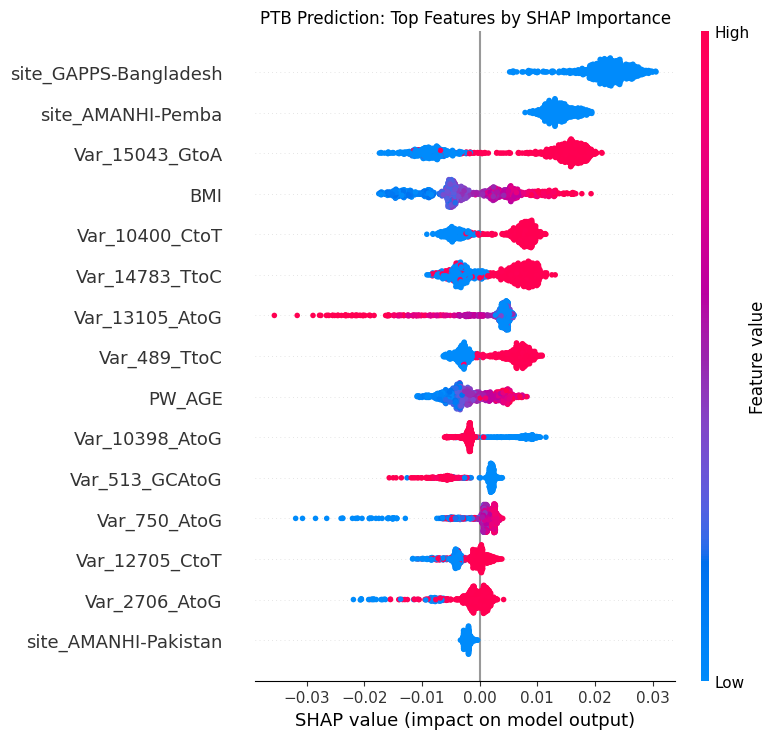

In [30]:
#PTB Random Forest
X_rf = X_all.copy()
y_rf = heteroplasmy_df['PTB']

print(f"Features: {X_rf.shape[1]} (variants + BMI + Age + site)")
print(f"Samples: {X_rf.shape[0]}")
print(f"PTB cases: {y_rf.sum()} ({y_rf.sum()/len(y_rf)*100:.1f}%)")

#Random Forest with cross-validation
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=5,
    class_weight='balanced'
)

from sklearn.model_selection import cross_val_score
cv_score = cross_val_score(rf_model, X_rf, y_rf, cv=5, scoring='roc_auc')
print(f"\nPTB ROC-AUC (5-fold CV): {cv_score.mean():.3f}")

#Train final model
rf_final = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=5,
    class_weight='balanced'
)
rf_final.fit(X_rf, y_rf)

#Feature importance
importance = pd.DataFrame({
    'feature': X_rf.columns,
    'importance': rf_final.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 features by importance:")
print(importance.head(10).to_string())

sample_size = min(1000, len(X_rf))
X_sample = X_rf.iloc[:sample_size]

#SHAP visualization
explainer = shap.TreeExplainer(rf_final)
shap_values = explainer.shap_values(X_sample)

shap_values = shap_values[:, :, 1]

plt.figure(figsize=(12, 6))
shap.summary_plot(shap_values, X_sample, max_display=15, show=False)
plt.title('PTB Prediction: Top Features by SHAP Importance')
plt.tight_layout()
plt.show()

In [31]:
 #The random forest shows poor predictive performance (AUC = 0.45) for preterm birth, with site indicators and BMI as top predictors.

Gestational Age (ALL VARIANTS)

In [32]:
#GA Linear Regression

#Prepare data
X_ga = X_all.copy()
y_ga = heteroplasmy_df['GAGEBRTH'].astype(float)
mask = y_ga.notna()
X_ga = X_ga[mask]
y_ga = y_ga[mask]

#Fit model
X_const = sm.add_constant(X_ga.astype(float))
ols_model = sm.OLS(y_ga, X_const)
ols_result = ols_model.fit()

#Calculate adjusted p-values
ga_results = pd.DataFrame({
    'feature': X_const.columns,
    'coef': ols_result.params,
    'p_value': ols_result.pvalues
})
ga_results['p_adj_fdr'] = multipletests(ga_results['p_value'], method='fdr_bh')[1]

#Results
sig_ga = ga_results[ga_results['p_adj_fdr'] < 0.05]
print(f"Significant features (FDR < 0.05): {len(sig_ga)}")
print(sig_ga[['feature', 'coef', 'p_adj_fdr']].head(10).to_string())

Significant features (FDR < 0.05): 3
                                     feature        coef     p_adj_fdr
const                                  const  276.302745  0.000000e+00
site_AMANHI-Pakistan    site_AMANHI-Pakistan   -2.384870  3.203267e-06
site_GAPPS-Bangladesh  site_GAPPS-Bangladesh   -2.789886  1.421261e-11


In [33]:
#Site effects dominate with AMANHI-Pakistan (-2.4 days) and GAPPS-Bangladesh (-2.8 days) showing significantly shorter GA, while no individual mtDNA variants survive multiple testing correction.

In [34]:
#GA Mixed model

#Prepare data - use first 10 variants
variant_subset = variant_cols[:10]
mixed_data_ga = X_all[variant_subset + ['BMI', 'PW_AGE']].copy()
mixed_data_ga['GAGEBRTH'] = heteroplasmy_df['GAGEBRTH']
mixed_data_ga['site'] = heteroplasmy_df['site']
mixed_data_ga = mixed_data_ga.dropna()

#Fit mixed model
formula = f"GAGEBRTH ~ {' + '.join(variant_subset)} + BMI + PW_AGE"
mixed_model_ga = smf.mixedlm(formula, data=mixed_data_ga, groups=mixed_data_ga["site"])
mixed_result_ga = mixed_model_ga.fit()

#Calculate adjusted p-values
mixed_fixed_ga = pd.DataFrame({
    'feature': mixed_result_ga.params.index,
    'coef': mixed_result_ga.params.values,
    'p_value': mixed_result_ga.pvalues.values
}).drop(index='Group Var', errors='ignore')

mixed_fixed_ga['p_adj_fdr'] = multipletests(mixed_fixed_ga['p_value'], method='fdr_bh')[1]

#Results
sig_mixed_ga = mixed_fixed_ga[mixed_fixed_ga['p_adj_fdr'] < 0.05]
print(f"Significant fixed effects (FDR < 0.05): {len(sig_mixed_ga)}")
print(sig_mixed_ga.to_string())

Significant fixed effects (FDR < 0.05): 1
     feature        coef  p_value  p_adj_fdr
0  Intercept  274.676044      0.0        0.0


In [35]:
#When accounting for site as a random effect, no mitochondrial variants, BMI, or maternal age show a significant fixed effect on gestational age, suggesting site-level factors dominate.

GA R² (5-fold CV): -0.032


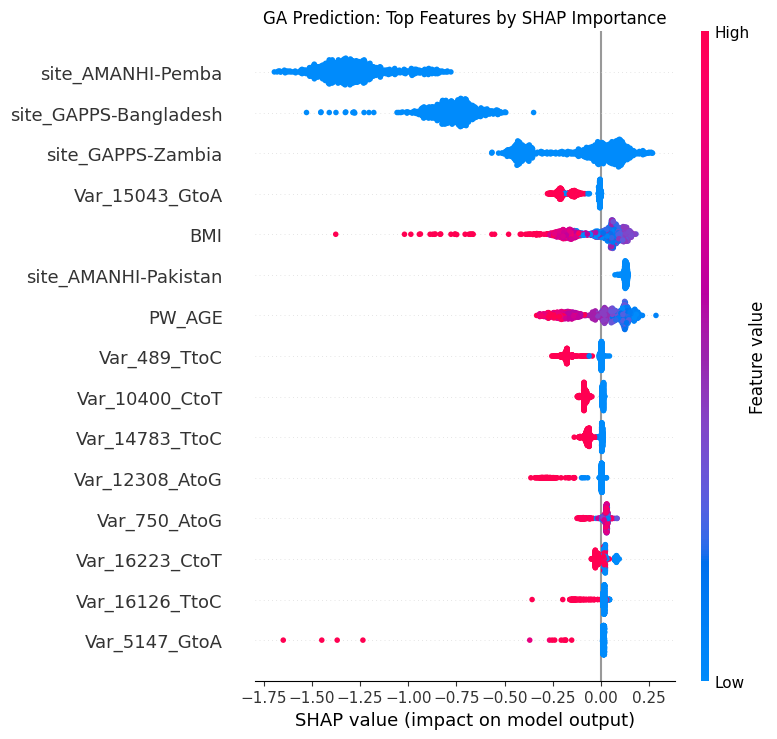

In [36]:
#GA Random Forest
X_rf_ga = X_all.copy()
y_rf_ga = heteroplasmy_df['GAGEBRTH'].astype(float)

#Remove missing GA values
mask = y_rf_ga.notna()
X_rf_ga = X_rf_ga[mask]
y_rf_ga = y_rf_ga[mask]

#Random Forest Regressor
rf_ga = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=5)
cv_score = cross_val_score(rf_ga, X_rf_ga, y_rf_ga, cv=5, scoring='r2')
print(f"GA R² (5-fold CV): {cv_score.mean():.3f}")

#Train model
rf_ga.fit(X_rf_ga, y_rf_ga)

#SHAP visualization
explainer = shap.TreeExplainer(rf_ga)
shap_values = explainer.shap_values(X_rf_ga.iloc[:1000])  # Sample for speed

plt.figure(figsize=(12, 6))
shap.summary_plot(shap_values, X_rf_ga.iloc[:1000], max_display=15, show=False)
plt.title('GA Prediction: Top Features by SHAP Importance')
plt.tight_layout()
plt.show()

In [37]:
#The model fails to predict gestational age accurately (R² = −0.032)
#The SHAP plot identifies study site and specific mitochondrial variants as top features, but they do not contribute to meaningful prediction.